3D Regression Plot for House Price Prediction
This program:
Creates a sample housing dataset.
Trains a Multiple Linear Regression model.
Draws a 3D scatter plot of the data points.
Displays the regression plane showing the relationship between:
Area (sq ft)
Number of Bedrooms
House Price

The plot will show:
Red dots → Actual house records.
Colored 3D plane → Regression model prediction surface.

Intercept: 6.229032258064549
Coefficients: [0.03796774 2.75806452]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


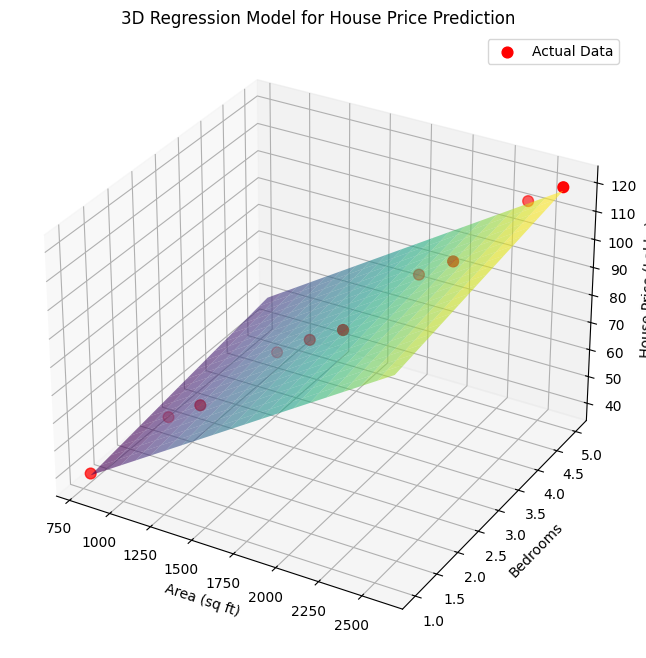

In [ ]:
# Import required libraries to build the model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Sample Housing Dataset
# -----------------------------
data = {
    'Area': [800,1000,1200,1400,1600,1800,2000,2200,2400,2600],
    'Bedrooms': [1,2,2,3,3,3,4,4,5,5],
    'Price': [40,50,58,67,75,82,92,100,112,120]
}

df = pd.DataFrame(data)

# -----------------------------
# Features (X) and Target(y)
# -----------------------------
X = df[['Area', 'Bedrooms']]
y = df['Price']

# -----------------------------
# Train the Regression Model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# -----------------------------
# Create Mesh Grid
# -----------------------------
area_range = np.linspace(df['Area'].min(),
                         df['Area'].max(),
                         20)

bedroom_range = np.linspace(df['Bedrooms'].min(),
                            df['Bedrooms'].max(),
                            20)

A, B = np.meshgrid(area_range,
                   bedroom_range)

# Predict Prices on Grid
Price_Pred = model.predict(
    np.c_[A.ravel(), B.ravel()]
)

Price_Pred = Price_Pred.reshape(A.shape)

# -----------------------------
# 3D Plot
# -----------------------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Actual Data Points
ax.scatter(df['Area'],
           df['Bedrooms'],
           df['Price'],
           color='red',
           s=60,
           label='Actual Data')

# Regression Plane
ax.plot_surface(A,
                B,
                Price_Pred,
                cmap='viridis',
                alpha=0.6)

# Labels
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('House Price (Lakhs)')

ax.set_title('3D Regression Model for House Price Prediction')

ax.legend()

plt.show()

Interpretation
1. Effect of Area
As Area increases, House Price generally increases.

2. Effect of Bedrooms
As the number of bedrooms increases, House Price also increases.

3. Regression Plane:
The plane represents the equation:
House Price=b0+b1(Area)+b2(Bedrooms)

Where:
b0 = Intercept
b1 = = Area coefficient
b2 = Bedroom coefficient

4. Business Insight
A real-estate company can use this model to estimate house prices based on:
Property Area & Number of Bedrooms
and visualize how both factors jointly influence the expected market price.